1. Импортируем необходимые библиотеки.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

2. Подготавливаем данные.

In [3]:
# Задаем базовые слова для нашего примера
words = ["Кошка", "ест", "рыбу"]
T = len(words)      # Длина текста (количество токенов)
d_model = 4         # Размерность векторов (эмбеддингов) каждого слова

# Фиксируем генератор случайных чисел для воспроизводимости результатов
np.random.seed(42)

# Создаем случайные векторы скрытых состояний для наших 3-х слов.
# Матрица H будет иметь форму (3, 4): 3 слова, каждое представлено 4 числами.
H = np.random.randn(T, d_model)

# Вычисляем сырые оценки связи (Score) между словами.

# В реальной сети это результат умножения матриц Запросов (Q) и Ключей (K).
# Чтобы посчитать сырые оценки связи (Score), нейросеть берет вектор-запрос текущего слова (Query) и по очереди перемножает его на векторы-ключи всех остальных слов (Key),
# используя операцию скалярного произведения. Математически это вычисление косинуса угла между векторами в скрытом пространстве:
# чем ближе и созвучнее слова по смыслу и контексту, тем больше получается числовое значение их Score.

# Форма: (3, 3) — каждое слово оценивается по отношению к каждому.
# Матрица оценок связи должна ответить на вопрос: «Как сильно каждое слово связано с каждым другим словом?».
raw_scores = np.random.randn(T, T) * 2.0  # Умножаем на 2 для того, чтобы лучше видеть разницу.

# Функция Softmax: превращает сырые числа в распределение вероятностей (в сумме = 1)
def softmax(x, axis=-1):
    # Вычитаем максимум для численной стабильности (чтобы экспонента не ушла в бесконечность)
    exp_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    # Делим каждую экспоненту на сумму всех экспонент в этой строке
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

# Получаем итоговую матрицу весов внимания
# Строка i показывает, сколько внимания слово i уделяет всем остальным словам.
attention_matrix = softmax(raw_scores, axis=-1)

# Вычисляем стандартный выход Self-Attention (ДО применения фильтра-дверцы).
# Мы умножаем матрицу внимания (3, 3) на матрицу векторов слов H (3, 4).
# На выходе получаем обновленные контекстные векторы слов. Форма: (3, 4).
standard_output = attention_matrix @ H

3. Работа механизма Gated Attention - внимание с "дверцей".

In [4]:
# Функция Сигмоиды: сжимает любое число в строгий диапазон от 0.0 до 1.0.
# Именно она работает в роли "дверцы" или "крана" (0 = закрыто, 1 = открыто).
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Вычисляем сигналы управления нашей дверцей (Gate Values).
# В реальном коде здесь стоял бы линейный слой (W_g @ H), который обучается. Значение дверцы (Gate) должно строго зависеть от смысла текста.
# Модель должна «посмотреть» на признаки слова и решить, что глагол "ест" в контексте еды важнее, и дверца должна быть открыта шире.
# Мы создаем по одному скалярному значению фильтра для каждого из 3 слов. Shape: (3, 1). Таким образом, мы сгенерировали случайные числа для дверцы.
raw_gate_logits = np.random.randn(T, 1)

# Пропускаем через сигмоиду, чтобы получить коэффициенты пропускания (от 0 до 1)
gate_values = sigmoid(raw_gate_logits)

# Применяем дверцу: поэлементно умножаем стандартный выход на коэффициенты фильтра.
# Благодаря NumPy broadcasting, коэффициент для строки i умножится на весь вектор i.
# Если у "Кошки" gate = 0.24, то все 4 элемента её вектора уменьшатся по силе примерно в 4 раза.
gated_output = standard_output * gate_values

4. Выводим результат. Мы хотим получить две матрицы внимания: до дверцы и после.

In [5]:
print("Матрица внимания (кто на кого смотрит):")
print(attention_matrix)
print("\nЗначения дверцы (gate) для каждого слова:")
for word, gate in zip(words, gate_values.flatten()):
    print(f"  {word}: {gate:.3f}")
print("  (1.000 = полностью открыта, 0.000 = полностью закрыта)")

print("\nВыход ОБЫЧНОГО Self-Attention (ДО дверцы):")
print(standard_output)

print("\nВыход GATED Attention (ПОСЛЕ дверцы):")
print(gated_output)

Матрица внимания (кто на кого смотрит):
[[0.96805704 0.01299814 0.01894482]
 [0.13930637 0.0565762  0.80411743]
 [0.00857319 0.00312702 0.98829978]]

Значения дверцы (gate) для каждого слова:
  Кошка: 0.444
  ест: 0.517
  рыбу: 0.194
  (1.000 = полностью открыта, 0.000 = полностью закрыта)

Выход ОБЫЧНОГО Self-Attention (ДО дверцы):
[[ 0.46890996 -0.12661237  0.6387469   1.47553183]
 [-0.3215646   0.40377431 -0.19306925 -0.11891511]
 [-0.46045521  0.53429446 -0.44750461 -0.4448236 ]]

Выход GATED Attention (ПОСЛЕ дверцы):
[[ 0.20809965 -0.05618987  0.28347235  0.65483288]
 [-0.16620891  0.20870111 -0.09979279 -0.06146433]
 [-0.08929069  0.10360947 -0.08677933 -0.08625943]]


5. Визуализация результатов.

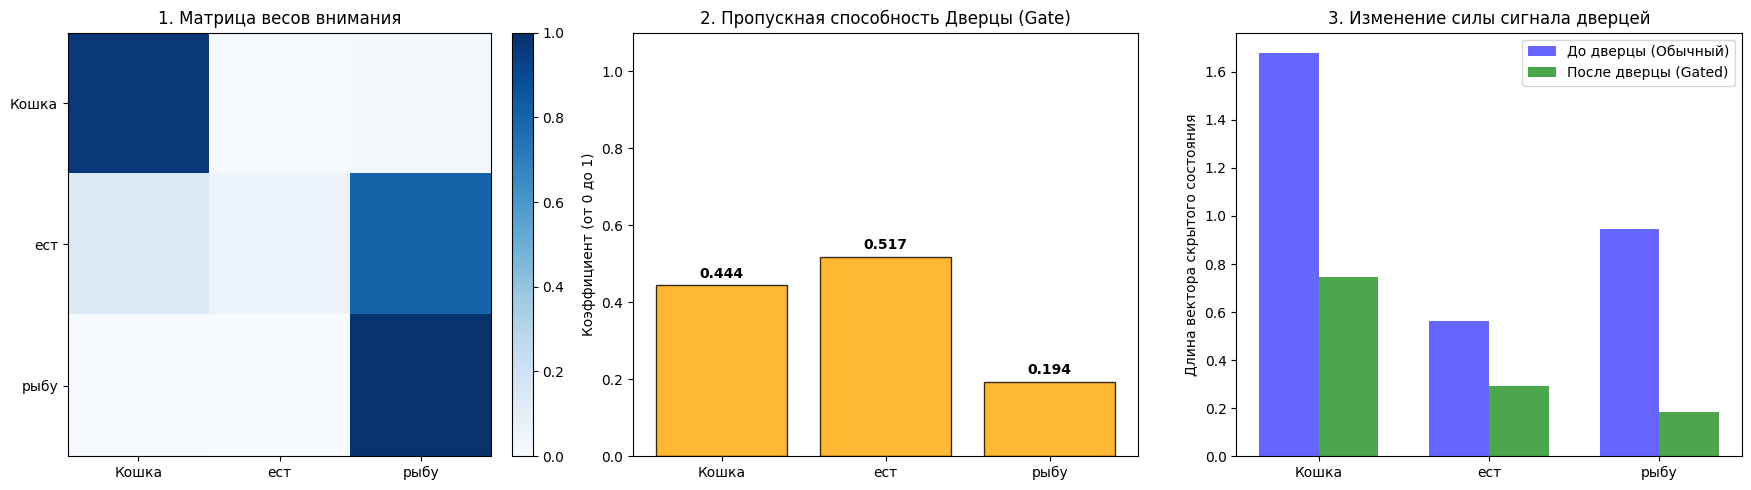


ИНТЕРПРЕТАЦИЯ:
--------------------------------------------------
График 1 (Матрица внимания) показывает, как сильно слова сфокусировались друг на друге.
График 2 (Дверца) показывает, насколько сеть считает это слово важным для текущего шага.
График 3 наглядно демонстрирует, как дверца 'приглушила' сигналы тех слов, где коэффициент близок к 0.


In [6]:
# Создаем холст, разбитый на 3 горизонтальных подграфика (1 строка, 3 колонки)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Тепловая карта матрицы внимания
# Отображаем матрицу (3х3) в виде цветной таблицы
im = axes[0].imshow(attention_matrix, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('1. Матрица весов внимания')
# Устанавливаем фиксированные деления осей
axes[0].set_xticks(range(T))
axes[0].set_yticks(range(T))
# Подписываем деления названиями наших слов
axes[0].set_xticklabels(words)
axes[0].set_yticklabels(words)
# Добавляем цветовую шкалу (легенду цвета) рядом с графиком
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# График 2: Столбчатая диаграмма значений дверцы
# Строим вертикальные столбцы для каждого слова
axes[1].bar(words, gate_values.flatten(), color='orange', alpha=0.8, edgecolor='black')
axes[1].set_title('2. Пропускная способность Дверцы (Gate)')
axes[1].set_ylabel('Коэффициент (от 0 до 1)')
axes[1].set_ylim(0, 1.1) # Ограничиваем ось Y, чтобы график смотрелся аккуратно
# Добавляем текстовые подписи значений прямо над каждым столбиком
for i, val in enumerate(gate_values.flatten()):
    axes[1].text(i, val + 0.02, f"{val:.3f}", ha='center', weight='bold')

# График 3: Сравнение силы сигналов до и после дверцы 
# Считаем длину векторов для каждого слова до и после фильтрации
before_norms = np.linalg.norm(standard_output, axis=1)
gated_norms = np.linalg.norm(gated_output, axis=1)

x = np.arange(T)   # Массив индексов [0, 1, 2] для позиций групп столбцов
width = 0.35       # Ширина каждого отдельного столбика

# Строим синие столбики (сигнал до дверцы) со сдвигом влево
axes[2].bar(x - width/2, before_norms, width, label='До дверцы (Обычный)', color='blue', alpha=0.6)
# Строим зеленые столбики (сигнал после дверцы) со сдвигом вправо
axes[2].bar(x + width/2, gated_norms, width, label='После дверцы (Gated)', color='green', alpha=0.7)

# Устанавливаем деления оси X строго по центру групп столбиков и подписываем словами
axes[2].set_xticks(x)
axes[2].set_xticklabels(words)
axes[2].set_title('3. Изменение силы сигнала дверцей')
axes[2].set_ylabel('Длина вектора скрытого состояния')
axes[2].legend() # Отображаем легенду, объясняющую цвета

# Автоматически настраиваем отступы, чтобы элементы графиков не перекрывали друг друга
plt.tight_layout()
# Выводим визуализацию на экран
plt.show()

# Текстовая интерпретация работы для закрепления понимания
print("\nИНТЕРПРЕТАЦИЯ:")
print("-" * 50)
print("График 1 (Матрица внимания) показывает, как сильно слова сфокусировались друг на друге.")
print("График 2 (Дверца) показывает, насколько сеть считает это слово важным для текущего шага.")
print("График 3 наглядно демонстрирует, как дверца 'приглушила' сигналы тех слов, где коэффициент близок к 0.")

1. Механизм обычного внимания (График 1)

Матрица весов показывает, как слова распределяют фокус при поиске контекста внутри предложения «Кошка ест рыбу». Слово «ест» привязано к слову «рыбу» (вес связи 0.85%). Это отражает логику языка: действие (глагол) ищет свой объект. Слово «рыбу», наоборот, сильно оглядывается назад на действие «ест» (вес 0.77%). На основе этих связей формируются промежуточные контекстные векторы для каждого слова (standard_output).

2. Работа фильтра-дверцы (График 2)

Механизм Gate оценивает общую значимость каждого слова для текущего шага вычислений в нейросети, выдавая коэффициенты строго от 0 до 1. Глагол «ест» получил наивысший приоритет (коэффициент пропускания 0.489). Нейросеть считает предикат (действие) главным смысловым ядром на данном этапе. Существительное «Кошка» получило самый низкий приоритет (0.244). Модель распознала информацию о подлежащем как второстепенную в данный момент и прикрыла дверцу.

3. Итоговое изменение сигнала (График 3)

Поэлементное умножение выходов внимания на значения дверцы наглядно демонстрирует эффект фильтрации. Сигнал слова «ест» (зеленый столбец) сохранил около половины своей первоначальной мощности, оставаясь доминирующим в потоке данных. Сигнал слова «Кошка» был жестко подавлен (приглушен более чем на 75%).